In [2]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20038600, 'total_supply': 20038600, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12649, 'cmc_rank': 1, 'last_updated': '2026-06-04T16:02:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1278026552232.14, 'quote': {'USD': {'price': 63778.2356168663, 'volume_24h': 65374060938.618324, 'cex_volume_24h': 65249626245.57022, 'dex_volume_24h': 124434693.04809505, 'volume_change_24h': 28.8748, 'percent_change_1h': -0.07688929, 'percent_change_24h': -3.1965378, 'percent_change_7d': -12.31713292, 'percent_change_30d': -21.75964701, 'percent_change_60d': -5.27936438, 'percent_change_90d': -6.93160079, 'market_cap': 1278026552232.137, 'market_cap_dominance': 57.6816, 'fully_diluted_market_cap': 1339342947954.19, 'tvl': None, 'last_updated': '20

In [3]:
type(data)

dict

In [4]:
import pandas as pd

pd.set_option('display.max.columns', None)
pd.set_option('display.max.rows', None)

In [5]:
# Normalizes the data making it look prettier.
df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.003860e+07,2.003860e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12649,1,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,1.278027e+12,"[mineable, pow, sha-256, store-of-value, state...",63778.235617,6.537406e+10,6.524963e+10,1.244347e+08,28.8748,-0.076889,-3.196538,-12.317133,-21.759647,-5.279364,-6.931601,1.278027e+12,57.6816,1.339343e+12,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
1,1027,Ethereum,ETH,ethereum,True,1.206849e+08,1.206849e+08,NaN,2015-08-07T00:00:00.000Z,12045,2,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,2.140781e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1773.859699,3.025044e+10,3.004782e+10,2.026230e+08,20.1051,0.183197,-3.089551,-10.644391,-25.476775,-13.680694,-10.312101,2.140781e+11,9.6733,2.140781e+11,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
2,825,Tether USDt,USDT,tether,True,1.875297e+11,1.931831e+11,NaN,2015-02-25T00:00:00.000Z,184320,3,2026-06-04T16:01:00.000Z,None,NaN,NaN,NaN,1.929727e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.998911,1.272091e+11,1.246323e+11,2.576810e+09,19.2322,-0.008918,0.024485,0.065241,-0.098900,-0.080296,-0.113280,1.873255e+11,8.4546,1.929727e+11,None,2026-06-04T16:01:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-04 17:03:47.941257
3,1839,BNB,BNB,bnb,False,1.347843e+08,1.347843e+08,1.347843e+08,2017-07-25T00:00:00.000Z,3266,4,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,8.162197e+10,"[marketplace, centralized-exchange, payments, ...",605.574747,2.550390e+09,2.498640e+09,5.175034e+07,20.5787,0.258798,-4.283772,-4.409021,-4.065377,2.077112,-3.568738,8.162197e+10,3.6928,8.162197e+10,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
4,3408,USDC,USDC,usd-coin,False,7.609445e+10,7.609445e+10,NaN,2018-10-08T00:00:00.000Z,40113,5,2026-06-04T16:01:00.000Z,None,NaN,6.090122e+10,6.088690e+10,7.607656e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999765,2.127881e+10,1.714069e+10,4.138125e+09,20.4636,0.006459,0.010271,0.019842,-0.014529,-0.013451,-0.005812,7.607656e+10,3.4402,7.607656e+10,None,2026-06-04T16:01:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-04 17:03:47.941257
5,52,XRP,XRP,xrp,False,6.197784e+10,9.998566e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1841,6,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,1.167413e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.167581,3.577237e+09,3.573841e+09,3.396619e+06,24.0109,-0.335977,-4.581883,-10.847007,-17.319281,-10.035680,-13.928323,7.236414e+10,3.2667,1.167581e+11,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
6,5426,Solana,SOL,solana,True,5.785606e+08,6.277872e+08,NaN,2020-04-10T00:00:00.000Z,1139,7,2026-06-04T16:01:00.000Z,None,NaN,5.252369e+08,3.654007e+10,4.367437e+10,"[pos, platform, solana-ecosystem, cms-holdings...",69.568747,5.973579e+09,5.973561e+09,1.800838e+04,32.8343,-0.174867,-5.070691,-14.079641,-18.665907,-12.645413,-17.781929,4.024974e+10,1.8166,4.367437e+10,None,2026-06-04T16:01:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
7,1958,TRON,TRX,tron,True,9.481810e+10,9.481810e+10,NaN,2017-09-13T00:00:00.000Z,1348,8,2026-06-04T16:02:00

In [31]:
def api_runner():
    global df

    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }
    
    session = Session()
    session.headers.update(headers)
    
    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

    df2 = pd.json_normalize(data['data'])
    df2['timestamp'] = pd.to_datetime('now')
    df_append = pd.DataFrame(df2)
    df = pd.concat([df,df_append])

    # If we want a CSV use this.
    #df = pd.json_normalize(data['data'])
    #df['timestamp'] = pd.to_datetime('now')
    #df

    #if not os.path.isfile(r'D:\Data Analyst Stuff\Python\Pandas\Reading In Files\CryptoApi.csv'):
        #df.to_csv(r'D:\Data Analyst Stuff\Python\Pandas\Reading In Files\CryptoApi.csv', header='column_names')
    #else:
        #df.to_csv(r'D:\Data Analyst Stuff\Python\Pandas\Reading In Files\CryptoApi.csv', mode='a', header=False)

In [32]:
import os 
from time import time 
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed successfully')
    sleep(60) # Sleep for 1 minute.
exit() 

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20038600, 'total_supply': 20038600, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12649, 'cmc_rank': 1, 'last_updated': '2026-06-04T16:37:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1271616462920.33, 'quote': {'USD': {'price': 63458.348533347205, 'volume_24h': 65805283319.2334, 'cex_volume_24h': 65678453557.968956, 'dex_volume_24h': 126829761.26444377, 'volume_change_24h': 28.9238, 'percent_change_1h': -0.64813136, 'percent_change_24h': -3.40842979, 'percent_change_7d': -13.13982123, 'percent_change_30d': -21.79984607, 'percent_change_60d': -5.76195133, 'percent_change_90d': -7.44818797, 'market_cap': 1271616462920.3313, 'market_cap_dominance': 57.6244, 'fully_diluted_market_cap': 1332625319200.29, 'tvl': None, 'last_updated': 

KeyboardInterrupt: 

In [33]:
df15 = pd.read_csv(r"D:\Data Analyst Stuff\Python\Pandas\Reading In Files\CryptoApi.csv")
df15

,Unnamed: 0,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,False,20038600.00000,20038600.00000,21000000.00000,2010-07-13T00:00:00.000Z,12649,1,2026-06-04T16:00:00.000Z,NaN,NaN,NaN,NaN,1279215661997.29004,"['mineable', 'pow', 'sha-256', 'store-of-value...",63837.57658,66900965569.96590,66779539777.28605,121425792.67985,31.44460,-0.09308,-3.27150,-12.26527,-21.71345,-5.16907,-6.88858,1279215661997.29077,57.73530,1340589108118.48999,NaN,2026-06-04T16:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:01:23.385666
1,1,1027,Ethereum,ETH,ethereum,True,120684919.77063,120684919.77063,NaN,2015-08-07T00:00:00.000Z,12045,2,2026-06-04T15:59:00.000Z,NaN,NaN,NaN,NaN,214505357662.59000,"['pos', 'smart-contracts', 'ethereum-ecosystem...",1777.39984,30984216455.38357,30780103648.28445,204112807.09909,22.41930,0.29562,-3.13155,-10.54864,-25.36939,-13.43920,-10.14220,214505357662.59308,9.69490,214505357662.59000,NaN,2026-06-04T15:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:01:23.385666
2,2,825,Tether USDt,USDT,tether,True,187529700104.60571,193183082470.09903,NaN,2015-02-25T00:00:00.000Z,184320,3,2026-06-04T15:59:00.000Z,NaN,NaN,NaN,NaN,192991269654.88000,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.99901,129350496691.70120,126774796437.14153,2575700254.55968,20.88700,-0.00288,0.03956,0.07101,-0.09852,-0.07674,-0.10123,187343500571.73227,8.46820,192991269654.88000,NaN,2026-06-04T15:59:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-04 17:01:23.385666
3,3,1839,BNB,BNB,bnb,False,134784307.43000,134784307.43000,134784307.99000,2017-07-25T00:00:00.000Z,3266,4,2026-06-04T16:00:00.000Z,NaN,NaN,NaN,NaN,81557541209.53000,"['marketplace', 'centralized-exchange', 'payme...",605.09671,2554239994.29225,2502494494.07202,51745500.22023,20.37840,0.23712,-4.40598,-4.49133,-4.13971,2.00767,-3.64768,81557541209.53244,3.68990,81557541548.39000,NaN,2026-06-04T16:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:01:23.385666
4,4,3408,USDC,USDC,usd-coin,False,76094446885.78799,76094446885.78799,NaN,2018-10-08T00:00:00.000Z,40113,5,2026-06-04T15:59:00.000Z,NaN,NaN,60901219650.23000,60885501560.52027,76074807552.63000,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.99974,21354288227.87431,17214637346.06341,4139650881.81084,19.98530,-0.00055,0.01594,0.00856,-0.01285,-0.01459,-0.02047,76074807552.62796,3.44010,76074807552.63000,NaN,2026-06-04T15:59:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-04 17:01:23.385666
5,5,52,XRP,XRP,xrp,False,61977843307.00000,99985656462.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1841,6,2026-06-04T16:00:00.000Z,NaN,NaN,NaN,NaN,116799097024.07001,"['medium-of-exchange', 'enterprise-solutions',...",1.16816,3586621284.06995,3583230279.71121,3391004.35875,23.60810,-0.24088,-4.57454,-10.82101,-17.28834,-9.95706,-13.88172,72399946051.34009,3.27400,116815852550.27000,NaN,2026-06-04T16:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:01:23.385666
6,6,5426,Solana,SOL,solana,True,578560626.38574,627787243.52939,NaN,2020-04-10T00:00:00.000Z,1139,7,2026-06-04T15:59:00.000Z,NaN,NaN,525236893.30000,36542422130.58306,43677180247.40000,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",69.57322,5978864699.23314,5978846691.89485,18007.33829,32.64660,-0.07456,-5.13327

In [34]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [35]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20038600.00000,20038600.00000,21000000.00000,2010-07-13T00:00:00.000Z,12649,1,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,1278026552232.13989,"[mineable, pow, sha-256, store-of-value, state...",63778.23562,65374060938.61832,65249626245.57022,124434693.04810,28.87480,-0.07689,-3.19654,-12.31713,-21.75965,-5.27936,-6.93160,1278026552232.13696,57.68160,1339342947954.18994,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
1,1027,Ethereum,ETH,ethereum,True,120684919.77063,120684919.77063,NaN,2015-08-07T00:00:00.000Z,12045,2,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,214078115407.51001,"[pos, smart-contracts, ethereum-ecosystem, coi...",1773.85970,30250442640.24616,30047819666.40538,202622973.84077,20.10510,0.18320,-3.08955,-10.64439,-25.47678,-13.68069,-10.31210,214078115407.51495,9.67330,214078115407.51001,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
2,825,Tether USDt,USDT,tether,True,187529700104.60571,193183082470.09906,NaN,2015-02-25T00:00:00.000Z,184320,3,2026-06-04T16:01:00.000Z,None,NaN,NaN,NaN,192972740570.67001,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99891,127209101583.04010,124632291148.23433,2576810434.80591,19.23220,-0.00892,0.02448,0.06524,-0.09890,-0.08030,-0.11328,187325513729.61548,8.45460,192972740570.67001,None,2026-06-04T16:01:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-04 17:03:47.941257
3,1839,BNB,BNB,bnb,False,134784307.43000,134784307.43000,134784307.43000,2017-07-25T00:00:00.000Z,3266,4,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,81621972915.75000,"[marketplace, centralized-exchange, payments, ...",605.57475,2550390197.32874,2498639860.41282,51750336.91592,20.57870,0.25880,-4.28377,-4.40902,-4.06538,2.07711,-3.56874,81621972915.75386,3.69280,81621972915.75000,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
4,3408,USDC,USDC,usd-coin,False,76094446885.78799,76094446885.78799,NaN,2018-10-08T00:00:00.000Z,40113,5,2026-06-04T16:01:00.000Z,None,NaN,60901219650.23000,60886904324.35929,76076560268.57001,"[medium-of-exchange, stablecoin, asset-backed-...",0.99976,21278811406.05377,17140686358.92142,4138125047.13235,20.46360,0.00646,0.01027,0.01984,-0.01453,-0.01345,-0.00581,76076560268.56789,3.44020,76076560268.57001,None,2026-06-04T16:01:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-04 17:03:47.941257
5,52,XRP,XRP,xrp,False,61977843307.00000,99985656462.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1841,6,2026-06-04T16:02:00.000Z,None,NaN,NaN,NaN,116741327498.58000,"[medium-of-exchange, enterprise-solutions, xrp...",1.16758,3577237332.12906,3573840713.55678,3396618.57228,24.01090,-0.33598,-4.58188,-10.84701,-17.31928,-10.03568,-13.92832,72364136609.01341,3.26670,116758074737.39999,None,2026-06-04T16:02:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-04 17:03:47.941257
6,5426,Solana,SOL,solana,True,578560626.38574,627787243.52939,NaN,2020-04-10T00:00:00.000Z,1139,7,2026-06-04T16:01:00.000Z,None,NaN,525236893.30000,36540072612.45753,43674371995.49000,"[pos, platform, solana-ecosystem, cms-holdings...",69.56875,5973578869.28128,5973560860.89678,18008.38450,32.83430,-0.17487,-5.07069,-14.07964,-

In [36]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.23897,-3.25004,-12.89835,-21.55665,-5.41785,-7.18437
Ethereum,-0.14416,-2.81182,-11.29838,-25.09305,-13.75812,-10.29800
Tether USDt,-0.00890,0.01797,0.06855,-0.10199,-0.07898,-0.10613
BNB,0.02935,-3.10611,-4.98467,-3.92442,2.08817,-3.91616
USDC,-0.00020,-0.01401,0.01274,-0.01888,-0.02378,-0.02677
XRP,-0.55027,-4.02094,-11.37633,-17.18056,-10.26811,-14.26565
Solana,-0.69303,-4.59170,-15.04800,-18.77303,-13.04883,-18.26997
TRON,0.01873,-1.12710,-5.95022,-3.88113,3.42462,15.53712
Hyperliquid,1.31427,-5.36233,16.08300,55.29915,91.60674,128.55733


In [37]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.23897
              quote.USD.percent_change_24h    -3.25004
              quote.USD.percent_change_7d    -12.89835
              quote.USD.percent_change_30d   -21.55665
              quote.USD.percent_change_60d    -5.41785
              quote.USD.percent_change_90d    -7.18437
Ethereum      quote.USD.percent_change_1h     -0.14416
              quote.USD.percent_change_24h    -2.81182
              quote.USD.percent_change_7d    -11.29838
              quote.USD.percent_change_30d   -25.09305
              quote.USD.percent_change_60d   -13.75812
              quote.USD.percent_change_90d   -10.29800
Tether USDt   quote.USD.percent_change_1h     -0.00890
              quote.USD.percent_change_24h     0.01797
              quote.USD.percent_change_7d      0.06855
              quote.USD.percent_change_30d    -0.10199
              quote.USD.percent_change_60d    -0.07898
              quote.US

In [38]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.23897
             quote.USD.percent_change_24h  -3.25004
             quote.USD.percent_change_7d  -12.89835
             quote.USD.percent_change_30d -21.55665
             quote.USD.percent_change_60d  -5.41785
             quote.USD.percent_change_90d  -7.18437
Ethereum     quote.USD.percent_change_1h   -0.14416
             quote.USD.percent_change_24h  -2.81182
             quote.USD.percent_change_7d  -11.29838
             quote.USD.percent_change_30d -25.09305
             quote.USD.percent_change_60d -13.75812
             quote.USD.percent_change_90d -10.29800
Tether USDt  quote.USD.percent_change_1h   -0.00890
             quote.USD.percent_change_24h   0.01797
             quote.USD.percent_change_7d    0.06855
             quote.USD.percent_change_30d  -0.10199
             quote.USD.percent_change_60d  -0.07898
             quote.USD.percent_change_90d  -0.10613
BNB          quote.USD.percent_change_1h    0.02935
             quote.USD.percent_change_24h  -3.10611
             quote.USD.percent_change_7d   -4.98467
             quote.USD.percent_change_30d  -3.92442
             quote.USD.percent_change_60d   2.08817
             quote.USD.percent_change_90d  -3.91616
USDC         quote.USD.percent_change_1h   -0.00020
             quote.USD.percent_change_24h  -0.01401
             quote.USD.percent_change_7d    0.01274
             quote.USD.percent_change_30d  -0.01888
             quote.USD.percent_change_60d  -0.02378
             quote.USD.percent_change_90d  -0.02677
XRP          quote.USD.percent_change_1h   -0.55027
             quote.USD.percent_change_24h  -4.02094
             quote.USD.percent_change_7d  -11.37633
             quote.USD.percent_change_30d -17.18056
             quote.USD.percent_change_60d -10.26811
             quote.USD.percent_change_90d -14.26565
Solana       quote.USD.percent_change_1h   -0.69303
             quote.USD.percent_change_24h  -4.59170
             quote.USD.percent_change_7d  -15.04800
             quote.USD.percent_change_30d -18.77303
             quote.USD.percent_change_60d -13.04883
             quote.USD.percent_change_90d -18.26997
TRON         quote.USD.percent_change_1h    0.01873
             quote.USD.percent_change_24h  -1.12710
             quote.USD.percent_change_7d   -5.95022
             quote.USD.percent_change_30d  -3.88113
             quote.USD.percent_change_60d   3.42462
             quote.USD.percent_change_90d  15.53712
Hyperliquid  quote.USD.percent_change_1h    1.31427
             quote.USD.percent_change_24h  -5.36233
             quote.USD.percent_change_7d   16.08300
             quote.USD.percent_change_30d  55.29915
             quote.USD.percent_change_60d  91.60674
             quote.USD.percent_change_90d 128.55733
Dogecoin     quote.USD.percent_change_1h   -0.29284
             quote.USD.percent_change_24h  -3.11059
             quote.USD.percent_change_7d   -9.72801
             quote.USD.percent_change_30d -20.43847
             quote.USD.percent_change_60d  -1.66079
             quote.USD.percent_change_90d  -1.90929
Zcash        quote.USD.percent_change_1h    1.06745
             quote.USD.percent_change_24h -10.45739
             quote.USD.percent_change_7d   -0.27877
             quote.USD.percent_change_30d  25.42446
             quote.USD.percent_change_60d 125.18356
             quote.USD.percent_change_90d 155.13032
UNUS SED LEO quote.USD.percent_change_1h   -0.01731
             quote.USD.percent_change_24h  -1.54162
             quote.USD.percent_change_7d   -1.19699
             quote.USD.percent_change_30d  -4.04261
             quote.USD.percent_change_60d  -1.68949
             quote.USD.percent_change_90d   9.53914
Stellar      quote.USD.percent_change_1h   -1.76712
             quote.USD.percent_change_24h  -7.08140
             quote.USD.percent_change_7d    1.71873
             quote.USD.percent_change_30d

In [13]:
df5.count()

values    90
dtype: int64

In [19]:
index = pd.Index(range(90))
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.07689
1,Bitcoin,quote.USD.percent_change_24h,-3.19654
2,Bitcoin,quote.USD.percent_change_7d,-12.31713
3,Bitcoin,quote.USD.percent_change_30d,-21.75965
4,Bitcoin,quote.USD.percent_change_60d,-5.27936
5,Bitcoin,quote.USD.percent_change_90d,-6.93160
6,Ethereum,quote.USD.percent_change_1h,0.18320
7,Ethereum,quote.USD.percent_change_24h,-3.08955
8,Ethereum,quote.USD.percent_change_7d,-10.64439
9,Ethereum,quote.USD.percent_change_30d,-25.47678


In [20]:
df7 = df6.rename(columns={'level_1':'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.07689
1,Bitcoin,quote.USD.percent_change_24h,-3.19654
2,Bitcoin,quote.USD.percent_change_7d,-12.31713
3,Bitcoin,quote.USD.percent_change_30d,-21.75965
4,Bitcoin,quote.USD.percent_change_60d,-5.27936
5,Bitcoin,quote.USD.percent_change_90d,-6.93160
6,Ethereum,quote.USD.percent_change_1h,0.18320
7,Ethereum,quote.USD.percent_change_24h,-3.08955
8,Ethereum,quote.USD.percent_change_7d,-10.64439
9,Ethereum,quote.USD.percent_change_30d,-25.47678


In [26]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,-0.07689
1,Bitcoin,24h,-3.19654
2,Bitcoin,7d,-12.31713
3,Bitcoin,30d,-21.75965
4,Bitcoin,60d,-5.27936
5,Bitcoin,90d,-6.93160
6,Ethereum,1h,0.18320
7,Ethereum,24h,-3.08955
8,Ethereum,7d,-10.64439
9,Ethereum,30d,-25.47678


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

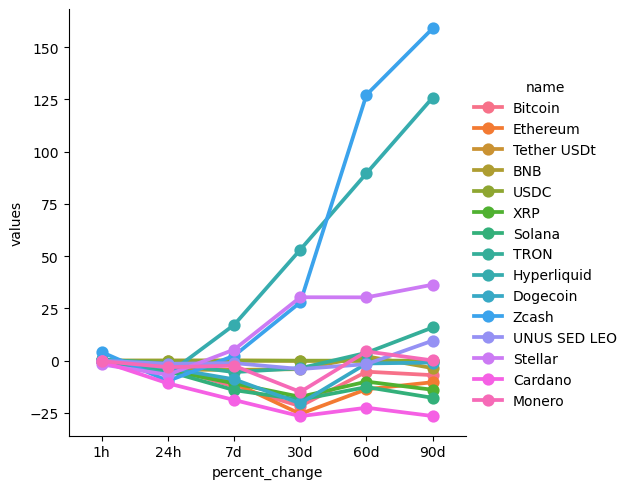

In [27]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [40]:
df10 = df[['name', 'quote.USD.price', 'timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,63778.23562,2026-06-04 17:03:47.941257
0,Bitcoin,63458.34853,2026-06-04 17:38:33.999285
0,Bitcoin,63507.65596,2026-06-04 17:39:34.207812
0,Bitcoin,63666.10083,2026-06-04 17:40:34.545174
0,Bitcoin,63666.10083,2026-06-04 17:41:34.906368
0,Bitcoin,63692.92786,2026-06-04 17:42:35.234806
0,Bitcoin,63677.40173,2026-06-04 17:43:35.454632
0,Bitcoin,63760.56892,2026-06-04 17:44:35.787812
0,Bitcoin,63756.93756,2026-06-04 17:45:36.142563


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

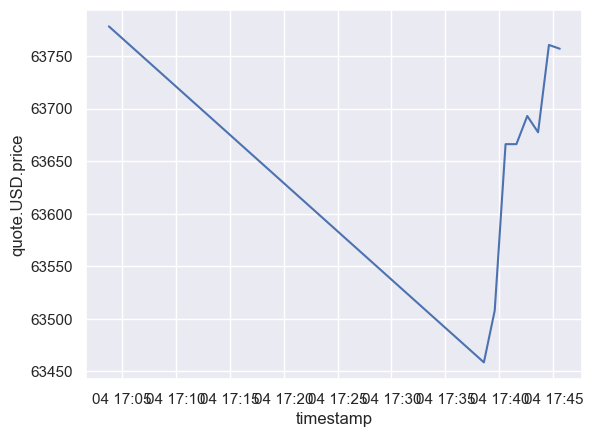

In [41]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)